<a href="https://colab.research.google.com/github/nakitava/python_math/blob/main/9.%20%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F%20%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2%20%D0%B8%20%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F%20%D0%A4%D1%83%D1%80%D1%8C%D0%B5/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2_%D0%B8_%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F_%D0%A4%D1%83%D1%80%D1%8C%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №9. Генерация сигналов и преобразования Фурье

# Блок №1. Базовый уровень

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq, fftshift
from scipy.signal import spectrogram
from scipy.io import wavfile

## **Задание 1: Генерация сигналов**



В этом задании вам нужно создать различные виды сигналов. Сигналы являются основой цифровой обработки сигналов, и умение их генерировать является важным навыком.













1. **Синусоидальный сигнал**: Синусоидальный сигнал можно представить как $A \sin(2\pi ft + \phi)$, где $A$ - амплитуда, $f$ - частота, $\phi$ - фаза.

- Создайте функцию, которая принимает эти параметры, а также длительность сигнала, и возвращает сгенерированный сигнал.

### Пример:



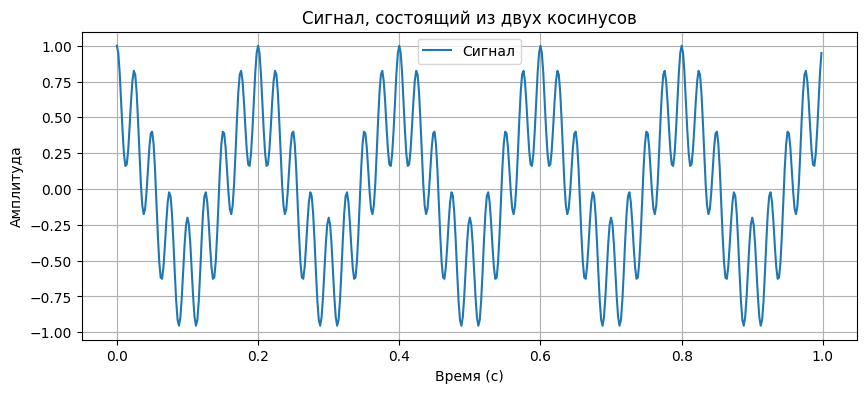

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Параметры времени
T = 1.0         # длительность сигнала в секундах
fs = 500.0      # частота дискретизации (в герцах)
t = np.arange(0, T, 1/fs) # массив времени

# Создание сигнала
f1 = 5.0        # частота первого косинуса
f2 = 40.0       # частота второго косинуса
a1 = 0.6        # амплитуда первого косинуса
a2 = 0.4        # амплитуда второго косинуса
signal = a1*np.cos(2*np.pi*f1*t) + a2*np.cos(2*np.pi*f2*t)

# Визуализация сигнала
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Cигнал, состоящий из двух косинусов')
plt.legend()
plt.grid(True)
plt.show()


### Ваш код:

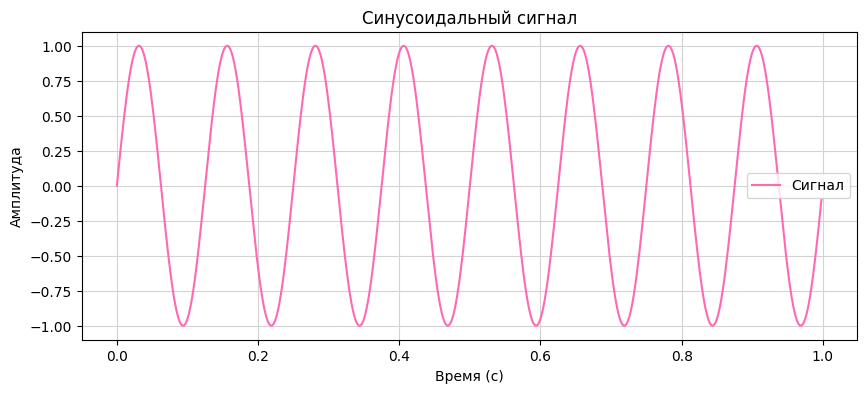

In [ ]:
T = 1
fs = 500
t = np.arange(0, T, 1 / fs)

A = 1
f = 8
phi = 0

meow = A * np.sin(2 * np.pi * f * t + phi)

plt.figure(figsize = (10, 4))
plt.plot(t, meow, label = 'Сигнал', color = 'hotpink')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Синусоидальный сигнал')
plt.legend()
plt.grid(color = 'lightgrey')
plt.show()

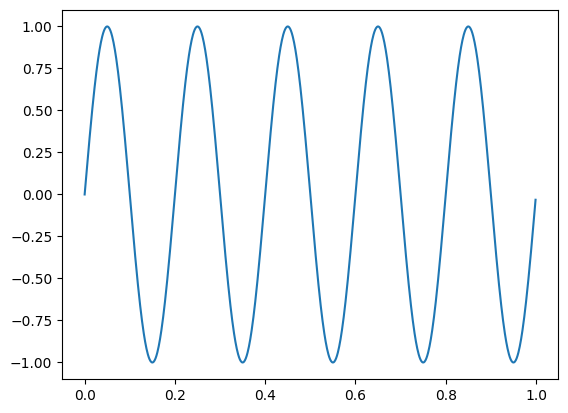

In [ ]:
# Пример

2. **Сумма синусоид**: Сигнал, состоящий из суммы двух синусоид, можно представить как $A_1 \sin(2\pi f_1t + \phi_1) + A_2 \sin(2\pi f_2t + \phi_2)$.

- Создайте функцию, которая принимает параметры для двух синусоид, а также длительность сигнала, и возвращает сгенерированный сигнал.

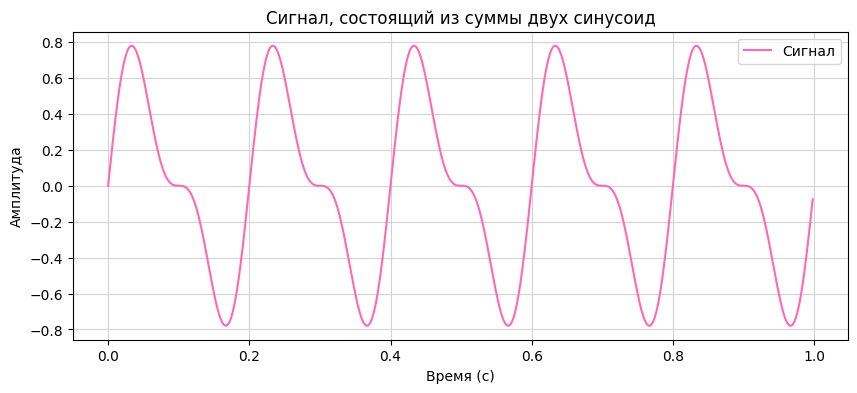

In [ ]:
T = 1
fs = 500
t = np.arange(0, T, 1 / fs)

A1 = 0.6
f1 = 5
phi1 = 0

A2 = 0.3
f2 = 10
phi2 = 0

meow = A1 * np.sin(2 * np.pi * f1 * t + phi1) + A2 * np.sin(2 * np.pi * f2 * t + phi2)

plt.figure(figsize = (10, 4))
plt.plot(t, meow, label = 'Сигнал', color = 'hotpink')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сигнал, состоящий из суммы двух синусоид')
plt.legend()
plt.grid(color = 'lightgrey')
plt.show()

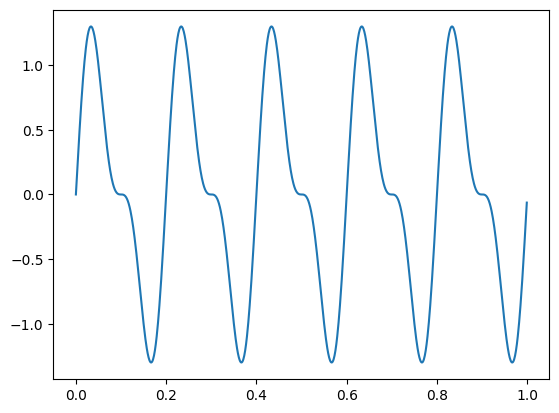

In [ ]:
# Пример

3. **Шумовой сигнал**: Шумовой сигнал (или белый шум) можно сгенерировать как случайные значения из нормального распределения.

- Создайте функцию, которая принимает амплитуду шума и длительность сигнала, и возвращает сгенерированный шумовой сигнал.

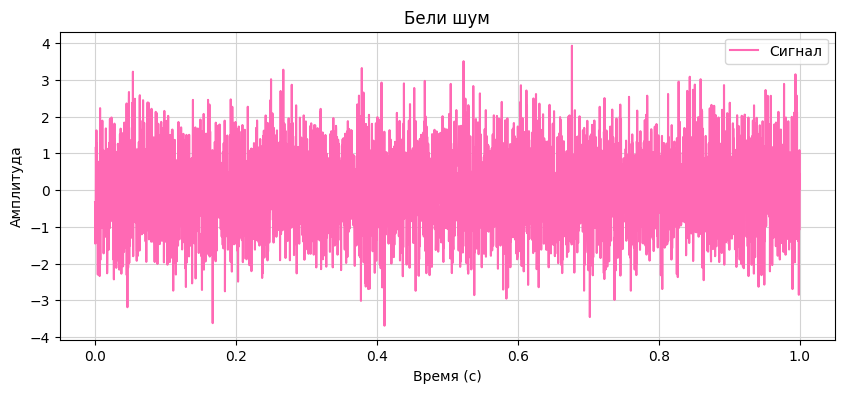

In [ ]:
T = 1
fs = 5000
t = np.arange(0, T, 1 / fs)

amplitude = 1
meow = amplitude * np.random.randn(len(t))

plt.figure(figsize = (10, 4))
plt.plot(t, meow, label = 'Сигнал', color = 'hotpink')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Бели шум')
plt.legend()
plt.grid(color = 'lightgrey')
plt.show()

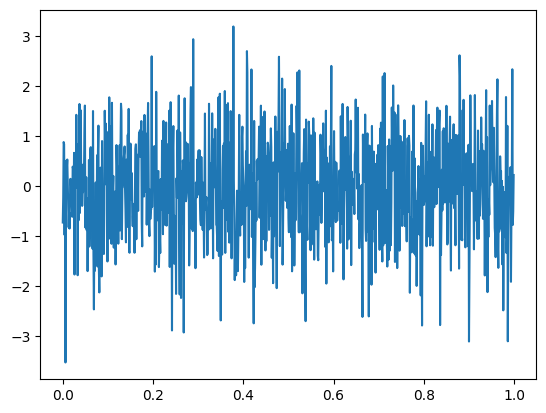

In [ ]:
# Пример

4. **Синусоида плюс шум**: Сигнал, который представляет собой сумму синусоиды и шума, можно сгенерировать путем сложения синусоидального и шумового сигналов.
- Создайте функцию, которая принимает параметры для синусоиды и шума, а также длительность сигнала, и возвращает сгенерированный сигнал.

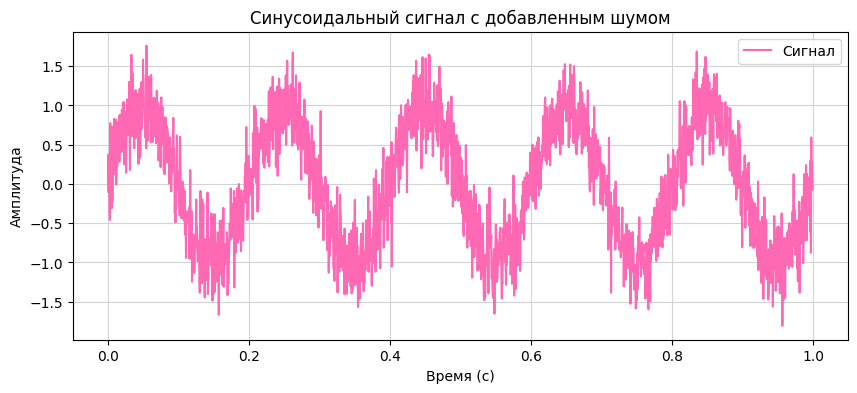

In [ ]:
T = 1
fs = 2000
t = np.arange(0, T, 1 / fs)

A = 1
f = 5
phi = 0

noise_amplitude = 0.3

sine_wave = A * np.sin(2 * np.pi * f * t + phi)
noise = noise_amplitude * np.random.randn(len(t))
meow = sine_wave + noise

plt.figure(figsize = (10, 4))
plt.plot(t, meow, label = 'Сигнал', color = 'hotpink')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Синусоидальный сигнал с добавленным шумом')
plt.legend()
plt.grid(color = 'lightgrey')
plt.show()

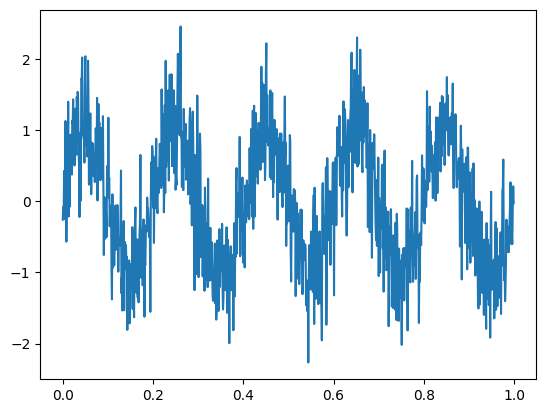

In [ ]:
# Пример

## **Задание 2: Преобразование Фурье**


Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Это основной инструмент для анализа сигналов. Создайте функцию, которая принимает сигнал и возвращает его преобразование Фурье.


1. Примените преобразование Фурье к синусоидальному сигналу и визуализируйте результат.


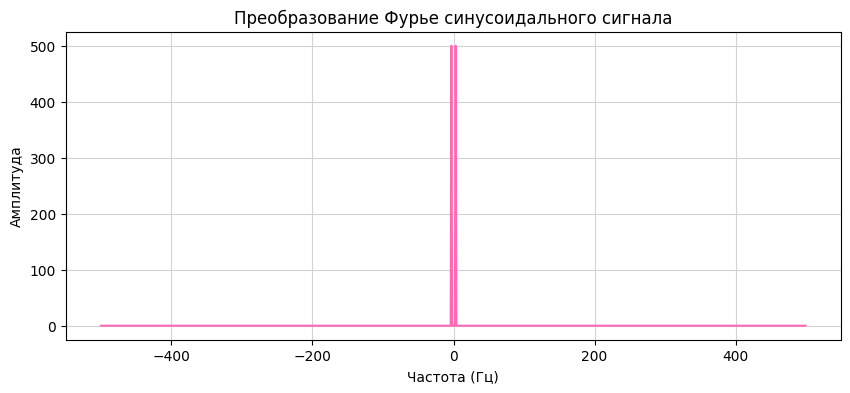

In [ ]:
T = 1
fs = 1000
t = np.arange(0, T, 1 / fs)

A = 1
f = 3
phi = 0

signal = A * np.sin(2 * np.pi * f * t + phi)

fft_result = fft(signal)
frequencies = fftfreq(len(t), 1/fs)

plt.figure(figsize = (10, 4))
plt.plot(fftshift(frequencies), fftshift(np.abs(fft_result)), color = 'hotpink')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Преобразование Фурье синусоидального сигнала')
plt.grid(color = 'lightgrey')
plt.show()

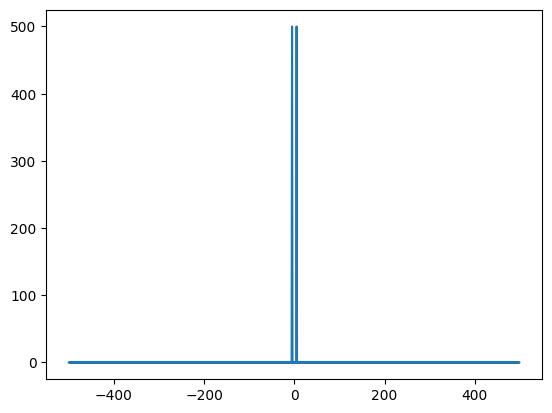

In [ ]:
# Пример

2. Примените преобразование Фурье к сигналу, состоящему из суммы двух синусоид, и визуализируйте результат.


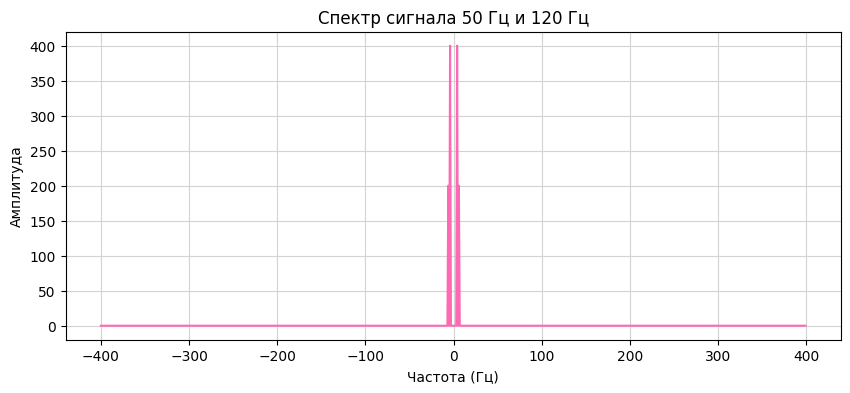

In [ ]:
fs = 800
t = np.linspace(0, 1, fs, endpoint = False)
signal = np.sin(2 * np.pi * 4 * t) + 0.5 * np.sin(2 * np.pi * 6 * t)

fft_result = fft(signal)
frequencies = fftfreq(len(t), 1 / fs)

plt.figure(figsize = (10, 4))
plt.plot(fftshift(frequencies), fftshift(np.abs(fft_result)), color = 'hotpink')
plt.title("Спектр сигнала 50 Гц и 120 Гц")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid(color='lightgrey')
plt.show()

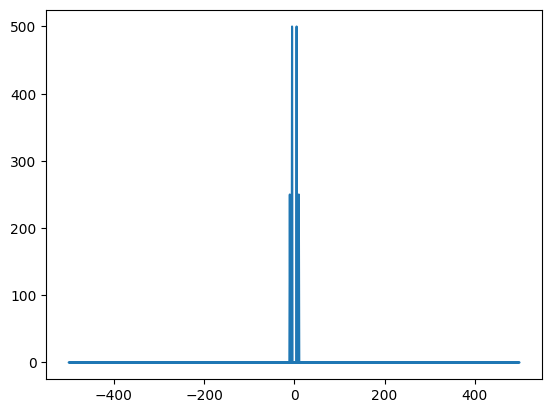

In [ ]:
# Пример

3. Примените преобразование Фурье к шумовому сигналу и визуализируйте результат.


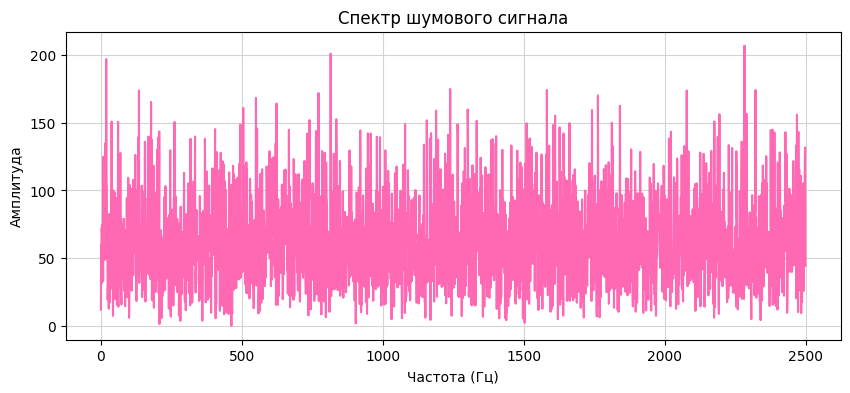

In [ ]:
fs = 5000
t = np.linspace(0, 1, fs, endpoint = False)

noise = np.random.randn(len(t))

fft_result = np.fft.fft(noise)
frequencies = np.fft.fftfreq(len(t), 1/fs)

plt.figure(figsize = (10, 4))
plt.plot(frequencies[:fs//2], np.abs(fft_result)[:fs//2], color = 'hotpink')
plt.title("Спектр шумового сигнала")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid(color = 'lightgrey')
plt.show()

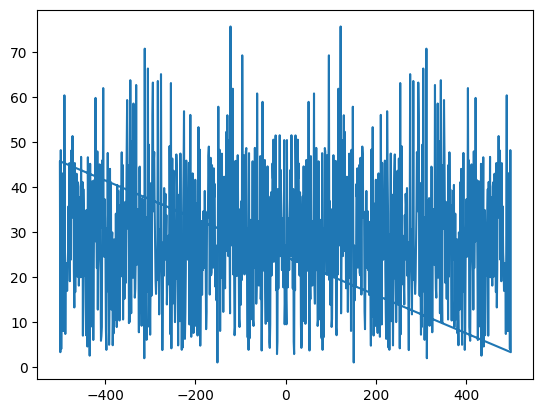

In [ ]:
# Пример

4. Примените преобразование Фурье к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результат.

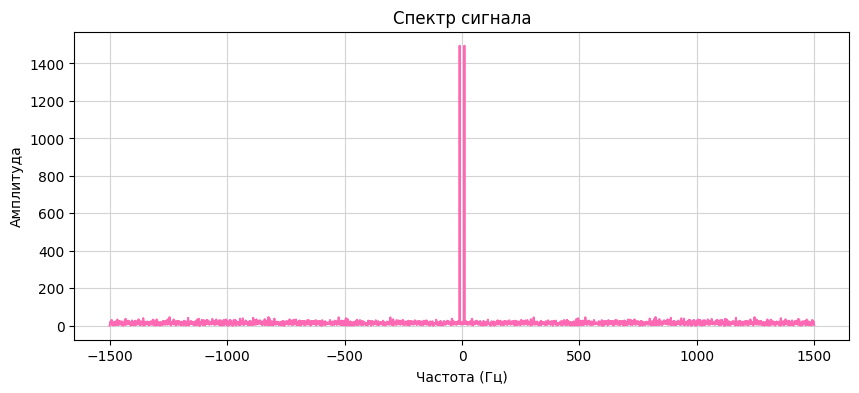

In [ ]:
fs = 3000
t = np.linspace(0, 1, fs, endpoint = False)
signal = np.sin(2 * np.pi * 10 * t) + 0.3 * np.random.randn(len(t))

fft_result = fft(signal)
frequencies = fftfreq(len(t), 1/fs)

plt.figure(figsize = (10, 4))
plt.plot(fftshift(frequencies), fftshift(np.abs(fft_result)), color = 'hotpink')
plt.title("Спектр сигнала")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid(color = 'lightgrey')
plt.show()

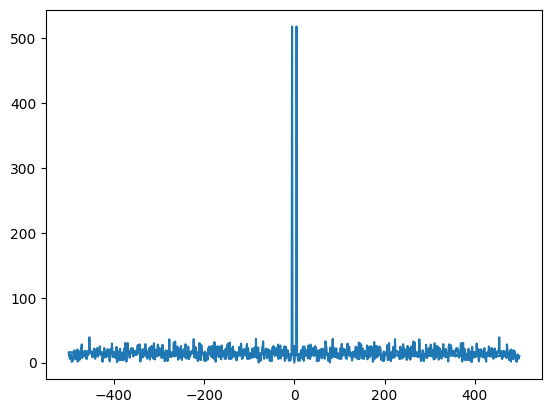

In [ ]:
# Пример

## **Задание 3: Фильтрация сигналов**

Фильтрация сигналов позволяет улучшить качество сигнала, убрав нежелательные частоты. Создайте функцию, которая принимает сигнал и частоту среза, и возвращает отфильтрованный сигнал.




1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.

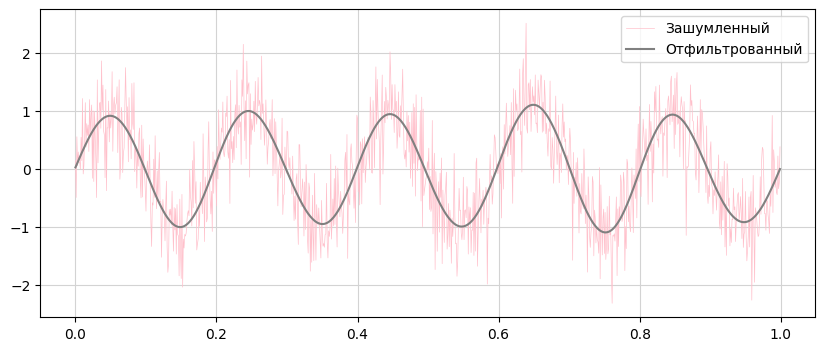

In [ ]:
fs = 1000
t = np.linspace(0, 1, fs, endpoint = False)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.random.randn(len(t))

cutoff = 10
yf = fft(signal)
xf = fftfreq(len(t), 1 / fs)
yf[np.abs(xf) > cutoff] = 0
filtered = np.real(ifft(yf))

plt.figure(figsize = (10, 4))
plt.plot(t, signal, label = 'Зашумленный', color = 'pink', linewidth = 0.5)
plt.plot(t, filtered, label = 'Отфильтрованный', color = 'gray')
plt.legend()
plt.grid(color = 'lightgrey')
plt.show()

In [ ]:
# Пример

2. Примените эту функцию к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результаты до и после фильтрации.

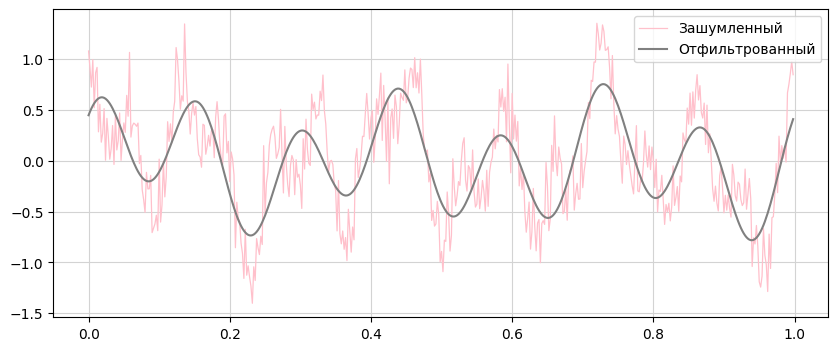

In [ ]:
fs = 500
t = np.linspace(0, 1, fs, endpoint = False)

signal = (0.3 * np.sin(2 * np.pi * 3 * t) +
          0.5 * np.sin(2 * np.pi * 7 * t + 1) +
          0.4 * np.sin(2 * np.pi * 15 * t + 2) +
          0.2 * np.random.randn(len(t)))

cutoff = 8
yf = fft(signal)
xf = fftfreq(len(t), 1 / fs)
yf[np.abs(xf) > cutoff] = 0
yf[np.abs(xf) < 1] = 0
filtered = np.real(ifft(yf))

plt.figure(figsize = (10, 4))
plt.plot(t, signal, label='Зашумленный', color = 'pink', linewidth = 0.9)
plt.plot(t, filtered, label = 'Отфильтрованный', color = 'gray')
plt.legend()
plt.grid(color='lightgrey')
plt.show()

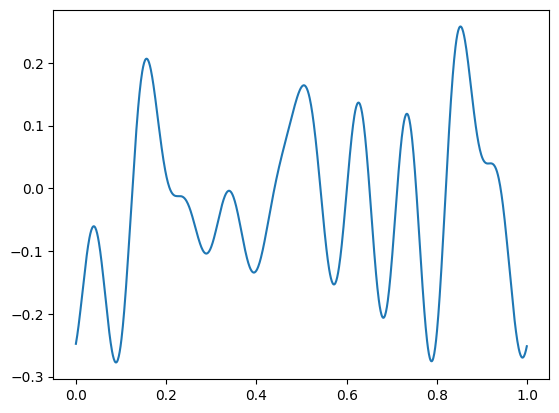

In [ ]:
# Пример

## **Задание 4: Анализ сигналов**

Анализ сигналов включает в себя различные методы и техники для изучения и понимания сигналов. Создайте функцию, которая принимает сигнал и возвращает его спектрограмму (**scipy.signal.spectrogram**).


**Спектрограмма** - это визуальное представление спектра частот сигнала во времени. Она показывает, какие частоты присутствуют в сигнале в каждый момент времени. Вот как правильно понимать спектрограмму:

- **Ось X**: Это время. Она показывает продолжительность сигнала. Каждый столбец на спектрограмме представляет собой отдельный момент времени.

- **Ось Y**: Это частота. Она показывает различные частоты, которые присутствуют в сигнале. Каждая строка на спектрограмме представляет собой отдельную частоту.

- **Значение**: Значение в каждой точке (x, y) показывает амплитуду (или интенсивность) данной частоты в данное время. Обычно более яркие цвета означают большую амплитуду, а более темные цвета - меньшую амплитуду.

Таким образом, спектрограмма позволяет вам видеть, как меняется спектральный состав сигнала во времени. Это может быть полезно во многих областях, включая анализ речи, музыку, радиосигналы и многое другое. Например, в анализе речи вы можете видеть, как меняются форманты (основные частоты) во время произношения различных звуков. В музыке вы можете видеть, как меняются ноты во время проигрывания песни.

1. Создайте функцию для вычисления и визуализации спектрограммы сигнала.


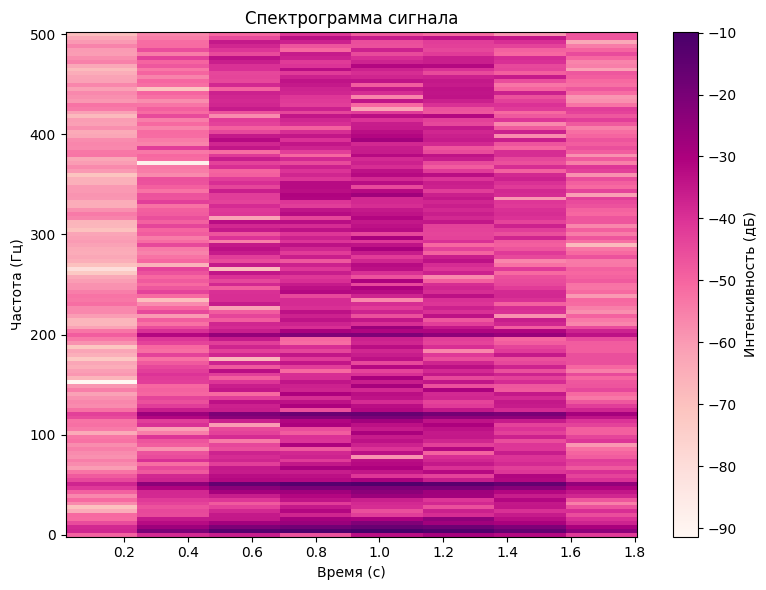

In [ ]:
def meow(signal, fs):
    f, t_spec, Sxx = spectrogram(signal, fs)
    plt.figure(figsize = (8, 6))
    plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading = 'gouraud', cmap = 'RdPu')
    plt.ylabel('Частота (Гц)')
    plt.xlabel('Время (с)')
    plt.colorbar(label = 'Интенсивность (дБ)')
    plt.title('Спектрограмма сигнала')
    plt.tight_layout()
    plt.show()

fs = 1000
t = np.linspace(0, 2, fs * 2, endpoint = False)

signal = (1.0 * np.sin(2 * np.pi * 5 * t) +
          0.8 * np.sin(2 * np.pi * 50 * t + 1.5) +
          0.5 * np.sin(2 * np.pi * 120 * t + 0.7) +
          0.3 * np.sin(2 * np.pi * 200 * t + 2.0) +
          0.4 * np.random.randn(len(t)))

window = np.hanning(len(t))
signal = signal * window

meow(signal, fs)

2. Примените эту функцию к различным сигналам, которые вы сгенерировали и проанализировали в предыдущих заданиях.

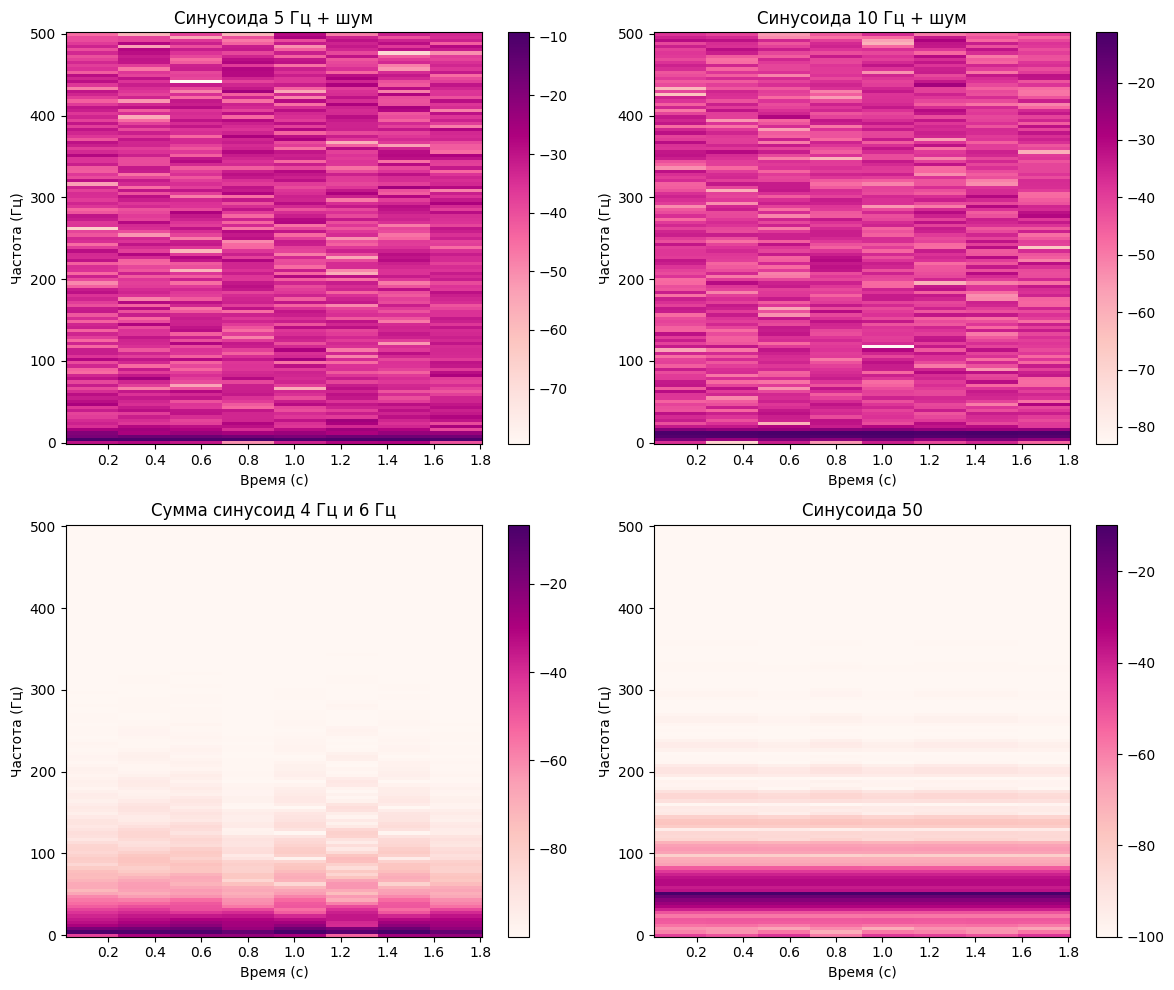

In [ ]:
def meow(signal, fs, ax, title):
    f, t_spec, Sxx = spectrogram(signal, fs)
    mesh = ax.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), cmap = 'RdPu')
    ax.set_ylabel('Частота (Гц)')
    ax.set_xlabel('Время (с)')
    ax.set_title(title)
    plt.colorbar(mesh, ax=  ax)

fs = 1000
t = np.linspace(0, 2, fs * 2, endpoint=False)

signal1 = np.sin(2 * np.pi * 5 * t) + 0.5 * np.random.randn(len(t))
signal2 = np.sin(2 * np.pi * 10 * t) + 0.3 * np.random.randn(len(t))
signal3 = np.sin(2 * np.pi * 4 * t) + 0.5 * np.sin(2 * np.pi * 6 * t)

A, f, phi = 1, 50, 0
signal4 = A * np.sin(2 * np.pi * f * t + phi)

fig, axes = plt.subplots(2, 2, figsize = (12, 10))
plt.subplots_adjust(hspace = 0.4, wspace = 0.4)

meow(signal1, fs, axes[0, 0], 'Синусоида 5 Гц + шум')
meow(signal2, fs, axes[0, 1], 'Синусоида 10 Гц + шум')
meow(signal3, fs, axes[1, 0], 'Сумма синусоид 4 Гц и 6 Гц')
meow(signal4, fs, axes[1, 1], f'Синусоида 50')

plt.tight_layout()
plt.show()

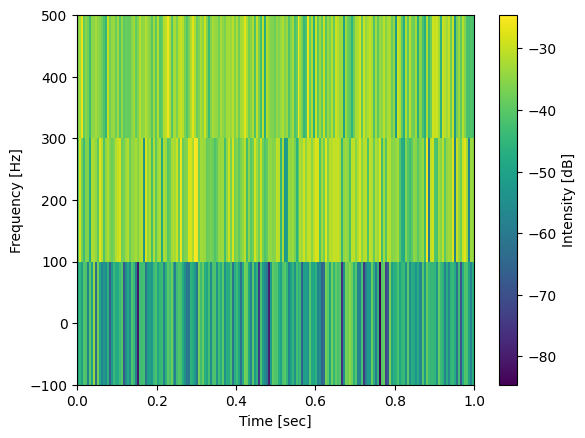

In [ ]:
# Пример

# Блок №2. Повышенный уровень

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.io import wavfile

## **Задание 1: Чтение и визуализация звукового файла**











В этом задании вам нужно использовать функцию `wavfile.read` из модуля `scipy.io` для чтения звукового файла. Эта функция возвращает частоту дискретизации и данные аудиосигнала. Затем вы должны визуализировать эти данные с помощью `matplotlib.pyplot.plot`. В результате вы получите график амплитуды звукового сигнала во времени.

1. Используйте библиотеку `scipy.io.wavfile` для чтения звукового файла.

In [92]:
fs, data = wavfile.read('/content/sample_data/Cherry Waves - Deftones.wav')
if len(data.shape) > 1:
    data = data[:, 0]

2. Визуализируйте временную форму звукового сигнала.

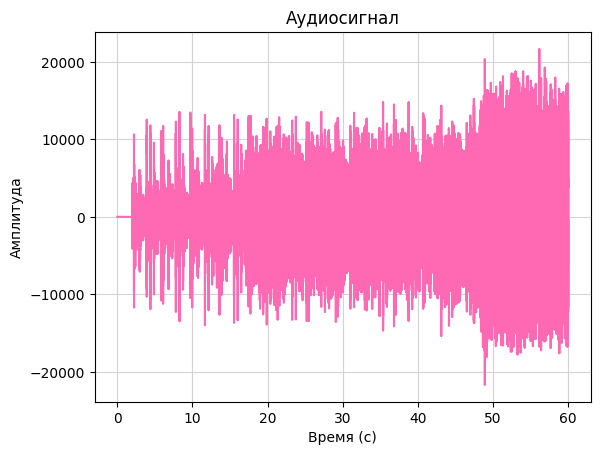

In [93]:
t = np.arange(len(data)) / fs
plt.plot(t, data, color = 'hotpink')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Аудиосигнал')
plt.grid(color = 'lightgrey')
plt.show()

In [94]:
# Пример

## **Задание 2: Применение преобразования Фурье**



Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Для его применения вы можете использовать функцию `fft` из модуля `scipy.fft`. Эта функция возвращает комплексные коэффициенты преобразования Фурье, которые затем можно визуализировать.

1. Примените преобразование Фурье к звуковому сигналу и визуализируйте спектр.

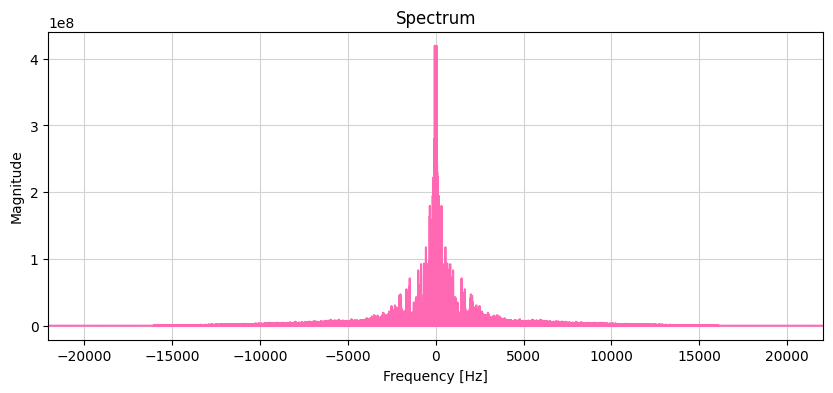

In [95]:
n = len(data)
yf = fft(data)
xf = fftfreq(n, 1 / fs)

idx = np.argsort(xf)
xf_sorted = xf[idx]
yf_sorted = np.abs(yf[idx])

plt.figure(figsize = (10, 4))
plt.plot(xf_sorted, yf_sorted, color = 'hotpink')
plt.title('Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.xlim(xf_sorted[0], xf_sorted[-1])
plt.grid(color = 'lightgrey')
plt.show()

In [96]:
# Пример

## **Задание 3: Фильтрация сигнала**



Фильтрация сигнала позволяет улучшить качество звука, убрав нежелательные частоты. Для этого вы можете использовать преобразование Фурье, затем обнулить некоторые из его коэффициентов и выполнить обратное преобразование Фурье с помощью функции `ifft` из модуля `scipy.fft`.

1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.


In [97]:
def meow(audio_data, cutoff_freq, sampling_sek):
    n = len(audio_data)
    yf = fft(audio_data)
    xf = fftfreq(n, 1/ sampling_sek)
    yf_filtered = yf.copy()
    yf_filtered[np.abs(xf) > cutoff_freq] = 0
    filtered_audio = np.real(ifft(yf_filtered))
    return filtered_audio.astype(audio_data.dtype)

cutoff = 4500
filtered_data = meow(data, cutoff, fs)

2. Примените эту функцию к звуковому сигналу и визуализируйте результаты до и после фильтрации.

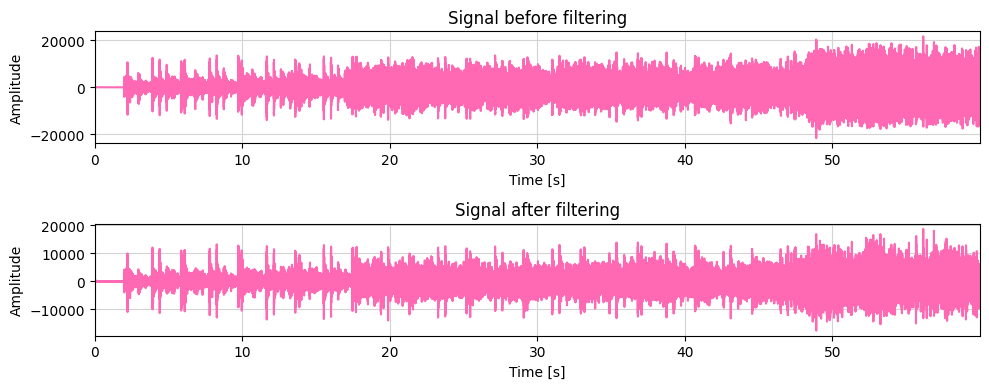

In [98]:
gersz_limit = 1000
filtered_data = meow(data, gersz_limit, fs)
t = np.arange(len(data)) / fs

plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(t, data, color = 'hotpink')
plt.title('Signal before filtering')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(color = 'lightgrey')
plt.xlim(0, t[-1])

plt.subplot(2, 1, 2)
plt.plot(t, filtered_data, color = 'hotpink')
plt.title(f'Signal after filtering')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(color = 'lightgrey')
plt.xlim(0, t[-1])

plt.tight_layout()
plt.show()

In [99]:
# Визуализация сигнала до фильтрации

In [100]:
# Визуализация сигнала после фильтрации

## **Задание 4: Обратное преобразование Фурье**



После фильтрации сигнала вы можете применить обратное преобразование Фурье для получения отфильтрованного звукового сигнала во временной области. Затем вы можете сохранить этот сигнал в новый звуковой файл с помощью функции `wavfile.write` из модуля `scipy.io`.

1. Примените обратное преобразование Фурье к отфильтрованному сигналу.


In [101]:
n = len(data)
yf = fft(data)
xf = fftfreq(n, 1 / fs)
gersz_limit = 4000

yf_filtered = yf.copy()
yf_filtered[np.abs(xf) < cutoff] = 0
recovered_signal = np.real(ifft(yf_filtered))
fin = recovered_signal.astype(data.dtype)

2. Сохраните полученный сигнал в новый звуковой файл.

In [102]:
output_filename = 'gav.wav'
wavfile.write(output_filename, fs, fin)